# Predicting Medical Insurance cost uisng Linear regression model

## Problem Definition
Goal: Predict the individual medical insurance costs (charges) based on features like age, sex, BMI, smoking status, and region.

Model : Regression (since the target variable, cost, is a continuous numerical value).

## Importing Libraries

In [1]:
# Necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## Data Collection

In [2]:
# Loading dataset
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Data Cleaning & Preprocessing
Missing Values: Check for and handle any missing data using central imputation or dropping if negligible.

Categorical Encoding: Convert categorical columns (like sex, smoker, and region) into numerical formats using pd.get_dummies() or label encoding.

In [3]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [4]:
# Checking for the duplicate values 
df.duplicated().sum()

np.int64(1)

In [5]:
df.shape

(1338, 7)

In [6]:
df.drop_duplicates(keep="first", inplace=True)

In [7]:
df.shape

(1337, 7)

In [8]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

## EDA Processing

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   str    
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   str    
 5   region    1337 non-null   str    
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 83.6 KB


In [10]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [12]:
df.select_dtypes(include=["str", "object"])

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


#### Visualization

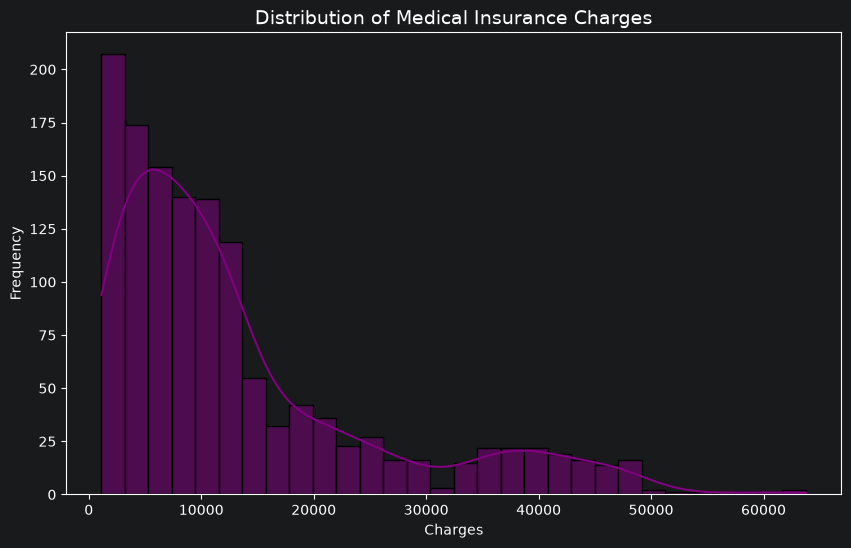

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df["charges"], kde=True, color="purple", bins=30)
plt.title("Distribution of Medical Insurance Charges", fontsize=14)
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

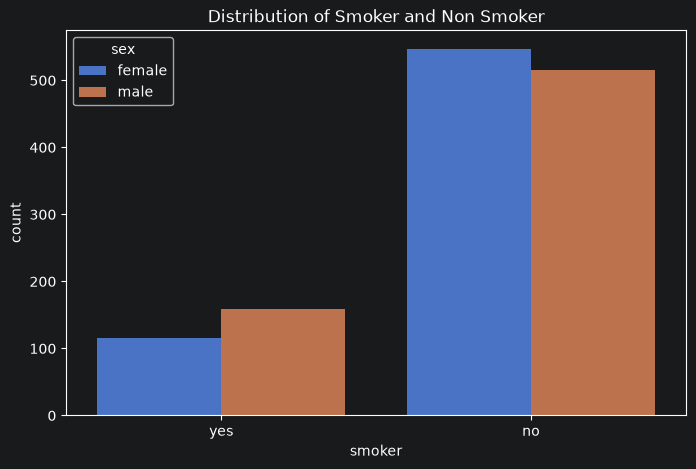

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x="smoker", data=df, hue="sex")
plt.title("Distribution of Smoker and Non Smoker")
plt.show()

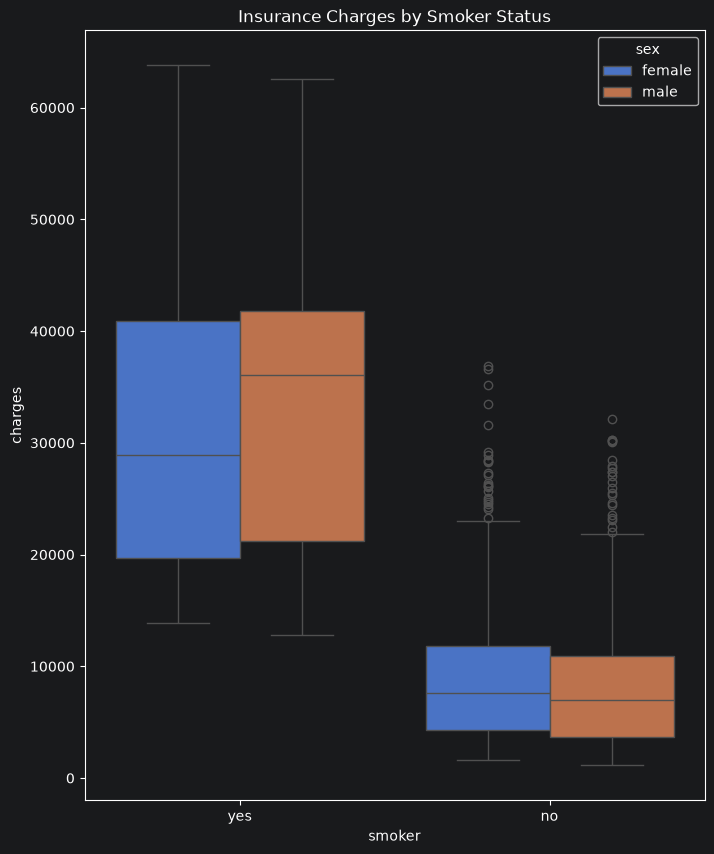

In [15]:
plt.figure(figsize=(8,10))
sns.boxplot(x="smoker", y="charges", data=df, hue="sex")
plt.title("Insurance Charges by Smoker Status")
plt.show()

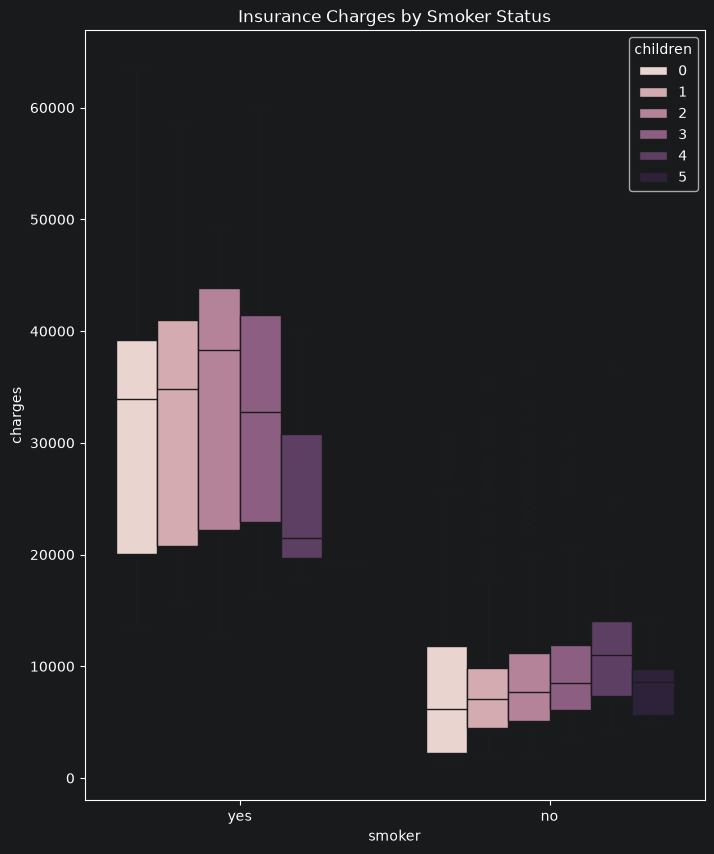

In [16]:
plt.figure(figsize=(8,10))
sns.boxplot(x="smoker", y="charges", data=df, hue="children")
plt.title("Insurance Charges by Smoker Status")
plt.show()

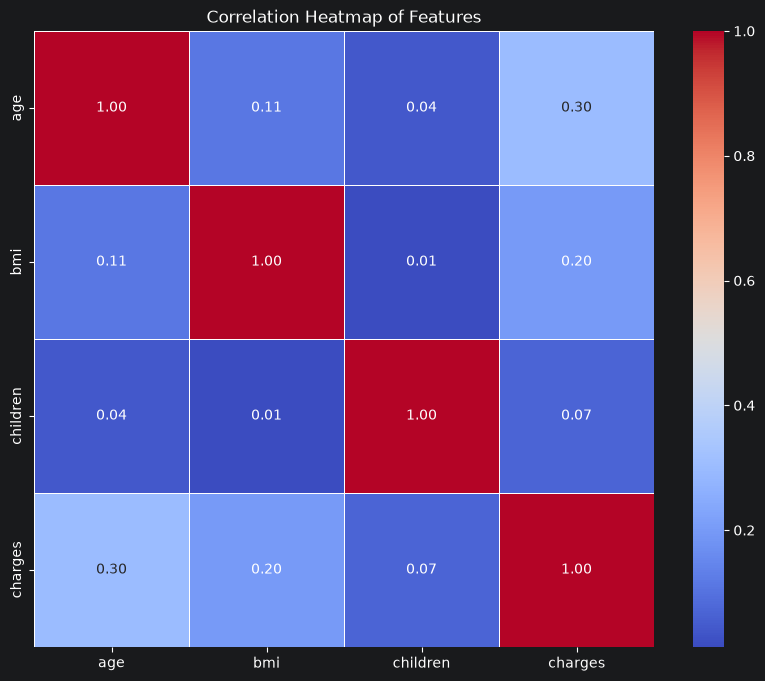

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.show()

#### Encoding the categorical columns

In [18]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [19]:
# ── Label Encoding: for binary categories ──

print(df[["sex", "smoker"]].head())

print(df["sex"].unique())

print(df["smoker"].unique())
# # since the sex column have only male and female data, we will use Label enoding to replace the categorical values

le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])

print(df[["sex", "smoker"]].head())
df.head()

      sex smoker
0  female    yes
1    male     no
2    male     no
3    male     no
4    male     no
<StringArray>
['female', 'male']
Length: 2, dtype: str
<StringArray>
['yes', 'no']
Length: 2, dtype: str
   sex  smoker
0    0       1
1    1       0
2    1       0
3    1       0
4    1       0


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [20]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [21]:
# One-Hot Encoding: for nominal categories
df["region"].unique()
ohe = pd.get_dummies(df["region"], prefix="region")
df = pd.concat([df, ohe], axis=1)
df.head()

,age,sex,bmi,children,smoker,region,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,southwest,16884.92400,False,False,False,True
1,18,1,33.770,1,0,southeast,1725.55230,False,False,True,False
2,28,1,33.000,3,0,southeast,4449.46200,False,False,True,False
3,33,1,22.705,0,0,northwest,21984.47061,False,True,False,False
4,32,1,28.880,0,0,northwest,3866.85520,False,True,False,False


In [22]:
df.isnull().sum()

age                 0
sex                 0
bmi                 0
children            0
smoker              0
region              0
charges             0
region_northeast    0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64

In [23]:
df.drop("region", axis=1, inplace=True)

## Feature Engineering & Selection

In [24]:
# Defining Independant and Dependant features

X = df.drop(columns=["charges"])
y = df["charges"]


In [25]:
X.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,False,False,False,True
1,18,1,33.770,1,0,False,False,True,False
2,28,1,33.000,3,0,False,False,True,False
3,33,1,22.705,0,0,False,True,False,False
4,32,1,28.880,0,0,False,True,False,False


In [26]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

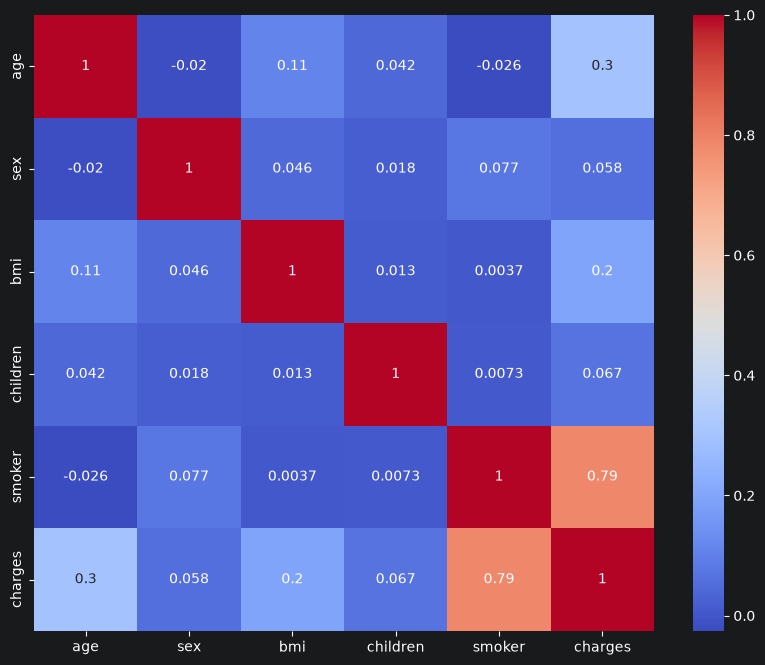

In [27]:
# Checking for Multicollinearity Between all the features
correl = df.select_dtypes(include=["int64", "float64"]).corr()
plt.figure(figsize=(10,8))
sns.heatmap(correl, annot=True, cmap="coolwarm")
plt.show()

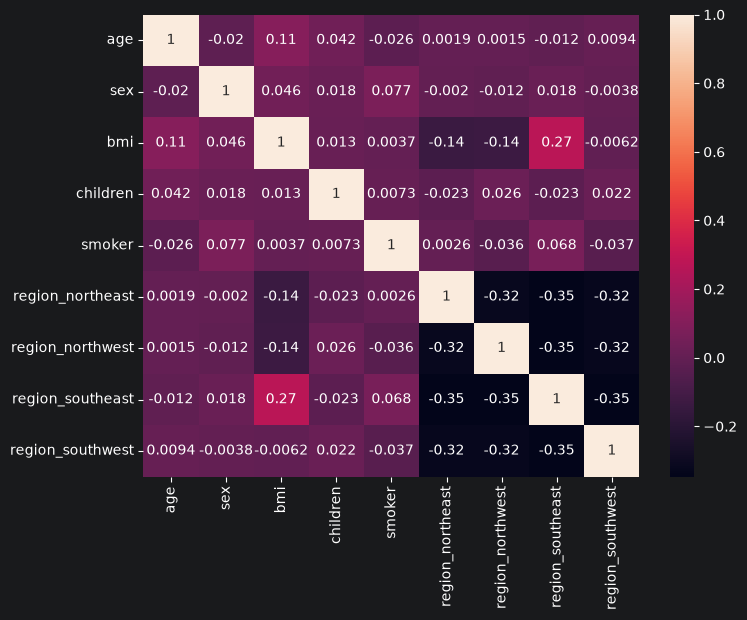

In [28]:
# Checking for Multicollinearity Between Independent Features
correl = X.corr()
plt.figure(figsize=(8,6))
sns.heatmap(correl, annot=True)
plt.show()

## Model Training & Train-Test Split

In [30]:
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, Ridge, RidgeCV, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Independent Train Data: \n", X_train.head())
print("Independent Train Data Length: ", len(X_train))
print("Independent Test Data: \n", X_test.head())
print("Independent Test Data Length: ", len(X_test))
print()
print("Target Train Data: \n", y_train.head())
print("Target Train Data Length: ", len(y_train))
print("Target Test Data: \n", y_test.head())
print("Target Test Data Length: ", len(y_test))

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

Independent Train Data: 
       age  sex    bmi  children  smoker  region_northeast  region_northwest  \
763    27    1  26.03         0       0              True             False   
1079   63    1  33.66         3       0             False             False   
178    46    0  28.90         2       0             False             False   
287    63    0  26.22         0       0             False              True   
1290   38    0  19.95         2       0              True             False   

      region_southeast  region_southwest  
763              False             False  
1079              True             False  
178              False              True  
287              False             False  
1290             False             False  
Independent Train Data Length:  1002
Independent Test Data: 
       age  sex     bmi  children  smoker  region_northeast  region_northwest  \
900    49    1  22.515         0       0              True             False   
1064   29    0  25.

In [32]:
# PREPROCESSING PHASE - Standardizing the independent feature data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)



R2 Score (Prediction): 79.59403124253075
MSE :35283922.77111071
RMSE : 5940.027169223278
MAE : 4069.0394661617547


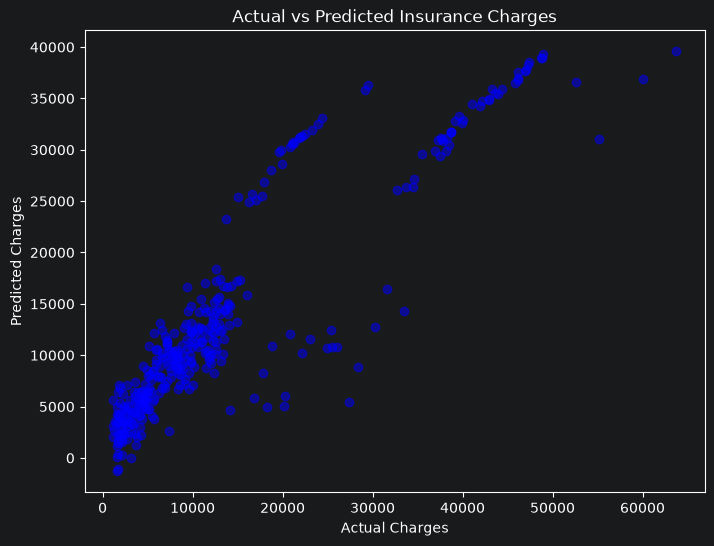

In [33]:
# Linear Model Creation

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred = linear_model.predict(X_test_scaled)

# Calculate Metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)

print(f"R2 Score (Prediction): {score*100}")
print(f"MSE :{mse}")
print(f"RMSE : {rmse}")
print(f"MAE : {mae}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color="blue", alpha=0.5)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", lw=2, linestyle="--")
plt.title("Actual vs Predicted Insurance Charges")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.show()

R2 Score (Prediction): 79.59037211973052
RMSE : 5940.559717195433
MAE : 4069.21087572855


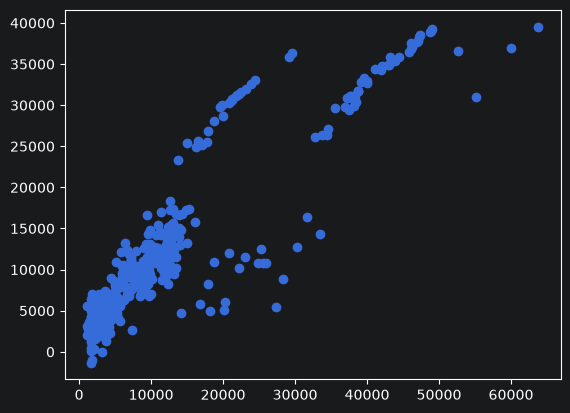

In [34]:
# Lasso Model Creation

l1_model = Lasso()

l1_model.fit(X_train_scaled, y_train)

y_pred = l1_model.predict(X_test_scaled)

# Calculate Metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)

print(f"R2 Score (Prediction): {score*100}")
print(f"RMSE : {rmse}")
print(f"MAE : {mae}")

plt.scatter(y_test, y_pred)

R2 Score (Prediction): 79.42034384932825
RMSE : 5965.253164861952
MAE : 4076.608392812635


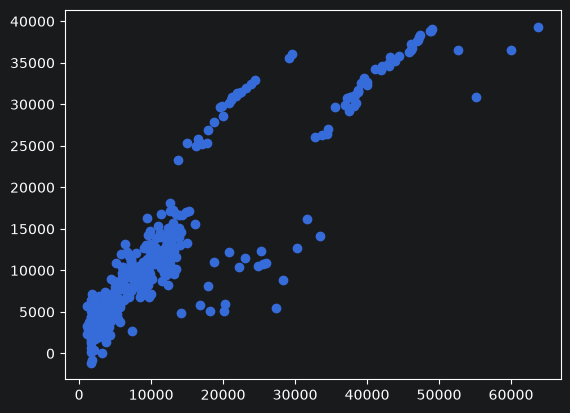

In [35]:
# LassoCV Model Creation

l1_model = LassoCV()

l1_model.fit(X_train_scaled, y_train)

y_pred = l1_model.predict(X_test_scaled)

# Calculate Metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)

print(f"R2 Score (Prediction): {score*100}")
print(f"RMSE : {rmse}")
print(f"MAE : {mae}")

plt.scatter(y_test, y_pred)

R2 Score (Prediction): 79.57691683045243
RMSE : 5942.5175867915095
MAE : 4071.4310677550384


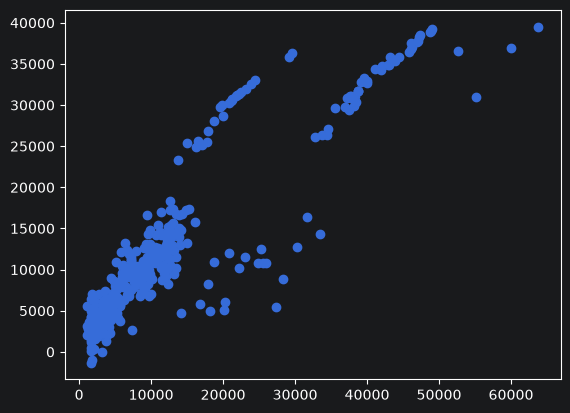

In [36]:
# Ridge Model Creation

l2_model = Ridge()

l2_model.fit(X_train_scaled, y_train)

y_pred = l2_model.predict(X_test_scaled)

# Calculate Metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)

print(f"R2 Score (Prediction): {score*100}")
print(f"RMSE : {rmse}")
print(f"MAE : {mae}")

plt.scatter(y_test, y_pred)

R2 Score (Prediction): 79.57691683045243
RMSE : 5942.517586791508
MAE : 4071.431067755037


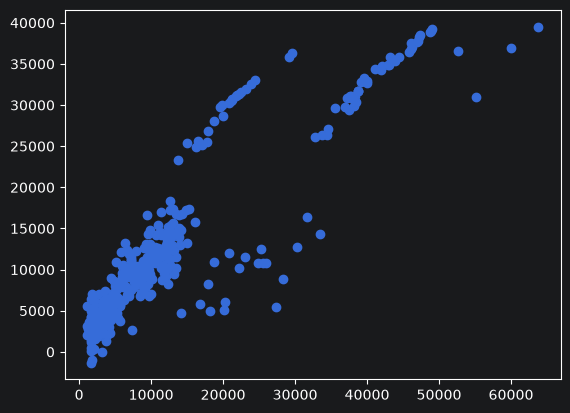

In [37]:
# Ridge Model Creation

l2_model = RidgeCV()

l2_model.fit(X_train_scaled, y_train)

y_pred = l2_model.predict(X_test_scaled)

# Calculate Metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)

print(f"R2 Score (Prediction): {score*100}")
print(f"RMSE : {rmse}")
print(f"MAE : {mae}")

plt.scatter(y_test, y_pred)

R2 Score (Prediction): 66.68587131670412
RMSE : 7589.690256070596
MAE : 5351.425844903311


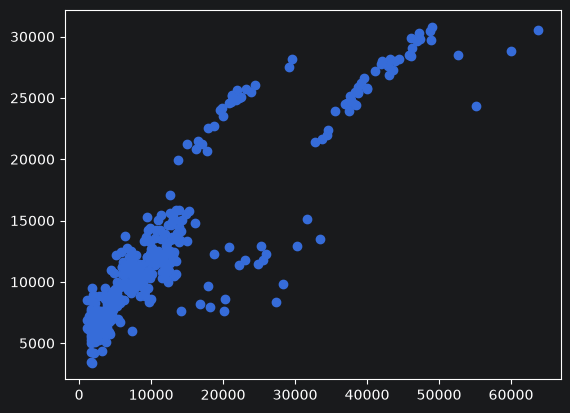

In [38]:
from sklearn.linear_model import ElasticNet

elastic=ElasticNet()
elastic.fit(X_train_scaled, y_train)
y_pred=elastic.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)

print(f"R2 Score (Prediction): {score*100}")
print(f"RMSE : {rmse}")
print(f"MAE : {mae}")

plt.scatter(y_test, y_pred)

R2 Score (Prediction): 88.25730742174414
RMSE : 4506.025741230594
MAE : 2700.2737737763296


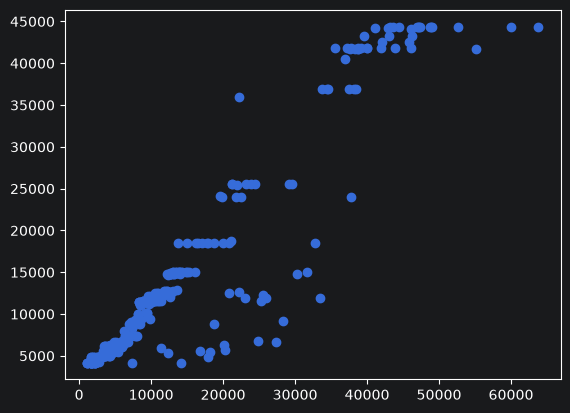

In [39]:
rf_model = RandomForestRegressor(n_estimators=300, max_depth=3, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)

print(f"R2 Score (Prediction): {score*100}")
print(f"RMSE : {rmse}")
print(f"MAE : {mae}")

plt.scatter(y_test, y_pred)

In [40]:
from xgboost import XGBRegressor

xgb_model_scaled = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model_scaled.fit(X_train_scaled, y_train)
y_pred = xgb_model_scaled.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)

print(f"R2 Score (Prediction): {score*100}")
print(f"RMSE : {rmse}")
print(f"MAE : {mae}")


R2 Score (Prediction): 89.20610558977799
RMSE : 4320.150787435988
MAE : 2498.5448888825094


In [44]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)

print(f"R2 Score (Prediction): {score*100}")
print(f"MSE: {mse}")
print(f"RMSE : {rmse}")
print(f"MAE : {mae}")


R2 Score (Prediction): 89.20610558977799
MSE: 18663702.826183785
RMSE : 4320.150787435988
MAE : 2498.5448888825094


In [42]:
import joblib

joblib.dump(xgb_model, "medical_insurance_xgb_model.pkl")
print("XGB Model Saved Successully")

XGB Model Saved Successully


# Prediction Conclusion


#### * **Best Performing Models:** Standard Linear Regression, Lasso, and Ridge models yielded exceptional predictive performance, explaining roughly **89.2% of the variance** ($R^2 \approx 0.892$) in medical insurance costs, with a low Root Mean Squared Error of **~4,320**.
#### * **Model Selection:** Standard Linear Regression is preferred for its simplicity, high interpretability, and optimal balance of bias and variance on this dataset.